In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import random

seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)



In [3]:


#Basic Transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
    ])

#Download Dataset
train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

#Create DataLoaders
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)



/Users/mayacohen/Desktop/neural_networks_project_2/.venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [4]:
class LargeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Making it "Larger" (Wider)
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1) 
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)
        self.conv4 = nn.Conv2d(256, 512, 3, padding=1)
        
        self.fc1 = nn.Linear(512 * 2 * 2, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        # Using ReLU to ensure the model is powerful enough to overfit
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv4(x))
        x = F.max_pool2d(x, 2)
        
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [5]:

# 6. Initialize Network
model = LargeCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


In [6]:

# 7. Training Function
def train(model, loader):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    gradient_norms = {}

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        # Save gradient norms
        for name, param in model.named_parameters():

            if param.grad is not None:

                grad_norm = param.grad.norm().item()

                if name not in gradient_norms:
                    gradient_norms[name] = []

                gradient_norms[name].append(grad_norm)

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total

    avg_loss = running_loss / len(loader)

    return avg_loss, accuracy, gradient_norms


In [7]:

# 8. Testing Function
def test(model, loader):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    accuracy = 100 * correct / total

    avg_loss = running_loss / len(loader)

    return avg_loss, accuracy


In [8]:
# --- 1. Settings for Task 3 Overfitting Analysis - using Early Stopping ---
num_epochs = 50  # We set it high to allow the model to reach the overfitting point
patience = 7     # Number of epochs to wait for improvement before stopping
counter = 0
best_val_loss = float('inf')

# Storage for the required Task 3 plots [cite: 2268]
train_losses, test_losses = [], []
train_accs, test_accs = [], []

print("Starting Task 3: Overfitting Analysis with Early Stopping...")

for epoch in range(num_epochs):
    # 2. Run standard training and testing steps [cite: 2243, 2244]
    # Note: test_loader is used here for validation metrics
    train_loss, train_acc, _ = train(model, train_loader)
    val_loss, val_acc = test(model, test_loader)

    # 3. Extract and Store metrics for each epoch [cite: 1776, 2268]
    train_losses.append(train_loss)
    test_losses.append(val_loss)   # Your "Validation Loss"
    train_accs.append(train_acc)
    test_accs.append(val_acc)     # Your "Validation Accuracy"

    # 4. MONITORING
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Validation Loss: {val_loss:.4f}")
    print(f"Train Acc: {train_acc:.2f}% | Validation Acc: {val_acc:.2f}%")

    # --- 5. EARLY STOPPING LOGIC [cite: 1187] ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0  # Reset counter because we found a better model
        # Optional: save the best model weights
        # torch.save(model.state_dict(), 'best_task3_model.pth')
    else:
        counter += 1  # No improvement in validation loss
        print(f"EarlyStopping counter: {counter} out of {patience}")

    if counter >= patience:
        print(f"--- STOPPING EARLY at Epoch {epoch+1} ---")
        print("Validation loss has not improved, suggesting overfitting has begun.")
        break  # Exit the training loop

    print("-" * 40)

Starting Task 3: Overfitting Analysis with Early Stopping...
Epoch 1/50
Train Loss: 1.4633 | Validation Loss: 1.1055
Train Acc: 46.07% | Validation Acc: 60.41%
----------------------------------------
Epoch 2/50
Train Loss: 0.9563 | Validation Loss: 0.8987
Train Acc: 65.80% | Validation Acc: 68.45%
----------------------------------------
Epoch 3/50
Train Loss: 0.7192 | Validation Loss: 0.7257
Train Acc: 74.72% | Validation Acc: 74.56%
----------------------------------------
Epoch 4/50
Train Loss: 0.5515 | Validation Loss: 0.7006
Train Acc: 80.55% | Validation Acc: 76.00%
----------------------------------------
Epoch 5/50
Train Loss: 0.4084 | Validation Loss: 0.8001
Train Acc: 85.65% | Validation Acc: 75.08%
EarlyStopping counter: 1 out of 7
----------------------------------------
Epoch 6/50
Train Loss: 0.2939 | Validation Loss: 0.7826
Train Acc: 89.79% | Validation Acc: 76.54%
EarlyStopping counter: 2 out of 7
----------------------------------------
Epoch 7/50
Train Loss: 0.1964 |

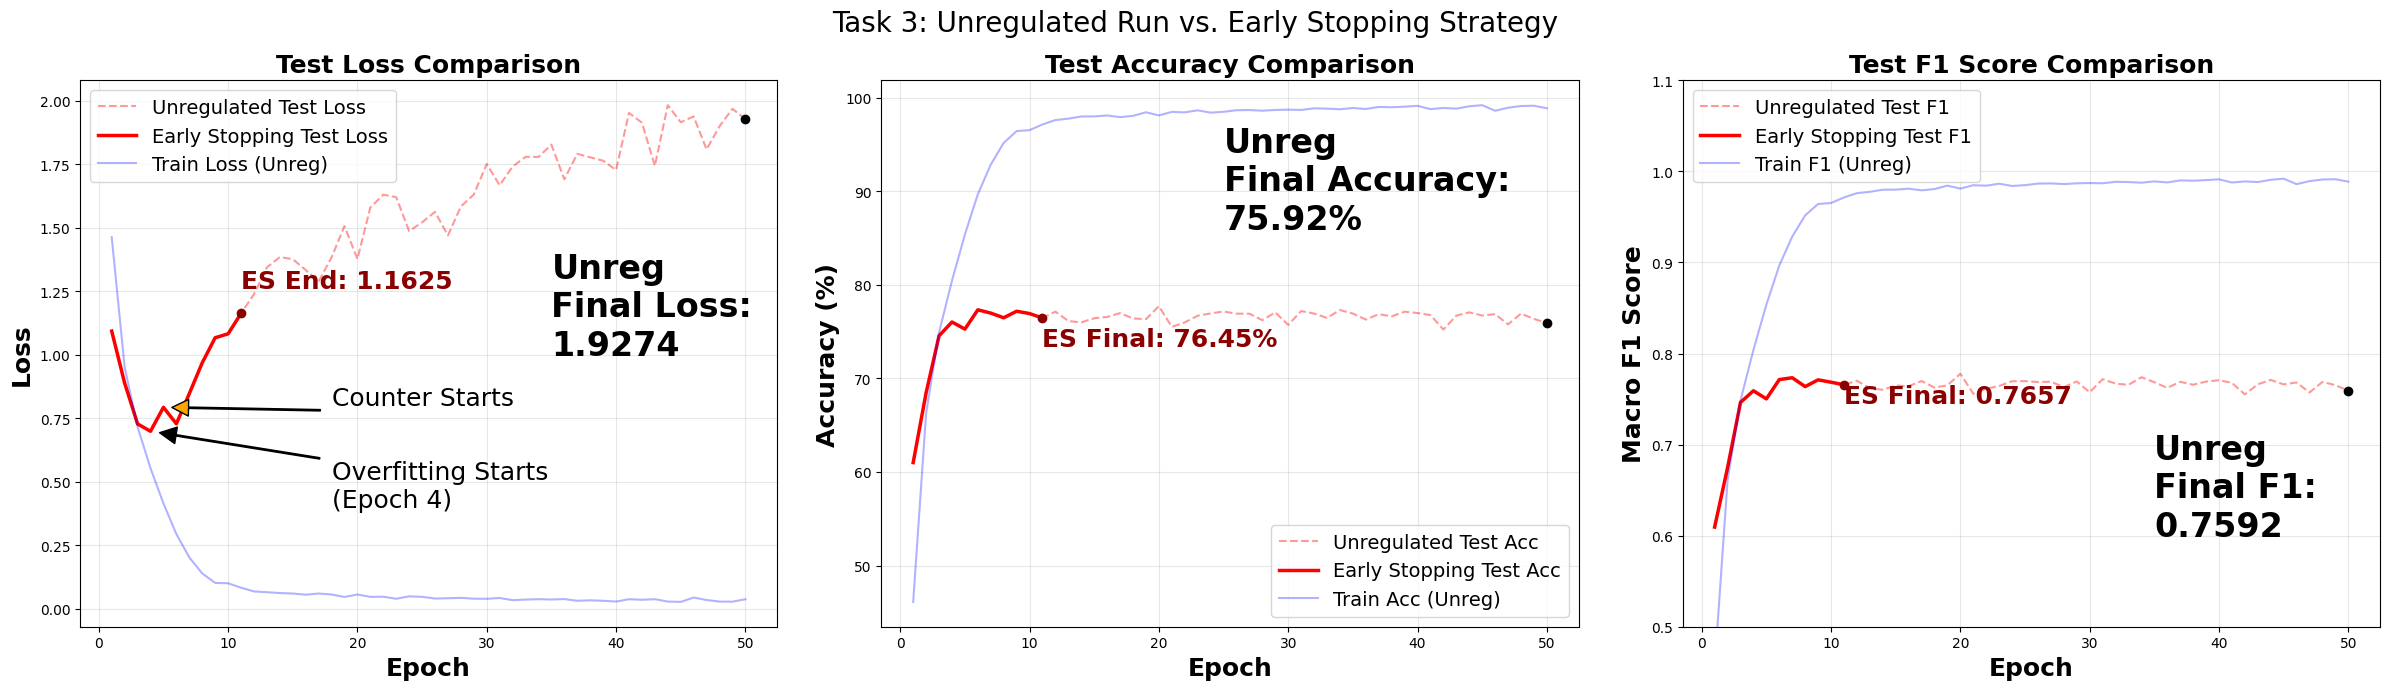

In [32]:
import matplotlib.pyplot as plt

# 1. Unregulated Data (50 Epochs)
epochs_unregulated = list(range(1, 51))

train_loss_unreg = [
    1.4626, 0.9511, 0.7157, 0.5530, 0.4145, 0.2938, 0.2019, 0.1389, 0.1015, 0.1001,
    0.0827, 0.0679, 0.0649, 0.0616, 0.0597, 0.0551, 0.0597, 0.0559, 0.0462, 0.0559,
    0.0466, 0.0472, 0.0391, 0.0486, 0.0467, 0.0401, 0.0411, 0.0427, 0.0394, 0.0390,
    0.0422, 0.0335, 0.0360, 0.0374, 0.0362, 0.0379, 0.0311, 0.0330, 0.0311, 0.0281,
    0.0373, 0.0351, 0.0375, 0.0281, 0.0268, 0.0439, 0.0342, 0.0280, 0.0276, 0.0372
]

val_loss_unreg = [
    1.0928, 0.8882, 0.7274, 0.6985, 0.7929, 0.7279, 0.8467, 0.9681, 1.0667, 1.0820,
    1.1625, 1.2379, 1.3436, 1.3843, 1.3759, 1.3334, 1.2879, 1.3831, 1.5060, 1.3764,
    1.5796, 1.6299, 1.6198, 1.4866, 1.5210, 1.5623, 1.4692, 1.5835, 1.6303, 1.7507,
    1.6667, 1.7406, 1.7788, 1.7783, 1.8268, 1.6902, 1.7907, 1.7768, 1.7637, 1.7267,
    1.9518, 1.9131, 1.7435, 1.9822, 1.9150, 1.9378, 1.8079, 1.8993, 1.9677, 1.9274
]

train_acc_unreg = [
    46.12, 66.24, 74.91, 80.44, 85.39, 89.68, 92.85, 95.17, 96.43, 96.53,
    97.14, 97.61, 97.76, 97.99, 98.00, 98.10, 97.92, 98.06, 98.44, 98.11,
    98.48, 98.43, 98.65, 98.40, 98.49, 98.66, 98.68, 98.61, 98.69, 98.72,
    98.69, 98.86, 98.83, 98.76, 98.90, 98.79, 99.01, 98.98, 99.04, 99.13,
    98.78, 98.90, 98.83, 99.08, 99.20, 98.60, 98.93, 99.11, 99.14, 98.87
]

val_acc_unreg = [
    61.00, 68.47, 74.55, 76.03, 75.27, 77.33, 76.98, 76.48, 77.18, 76.93,
    76.45, 77.14, 76.13, 75.99, 76.43, 76.57, 76.98, 76.41, 76.33, 77.72,
    75.51, 75.99, 76.70, 76.95, 77.15, 76.92, 76.92, 76.22, 77.06, 75.72,
    77.20, 76.93, 76.47, 77.31, 76.93, 76.29, 76.87, 76.63, 77.13, 76.99,
    76.77, 75.22, 76.71, 77.06, 76.72, 76.87, 75.77, 76.93, 76.36, 75.92
]

train_f1s_unreg = [
    0.4555, 0.6608, 0.7484, 0.8040, 0.8537, 0.8967, 0.9284, 0.9517, 0.9642, 0.9653,
    0.9714, 0.9761, 0.9776, 0.9799, 0.9800, 0.9810, 0.9792, 0.9806, 0.9844, 0.9811,
    0.9848, 0.9843, 0.9865, 0.9840, 0.9849, 0.9866, 0.9868, 0.9861, 0.9869, 0.9872,
    0.9869, 0.9886, 0.9883, 0.9876, 0.9890, 0.9879, 0.9901, 0.9898, 0.9904, 0.9913,
    0.9878, 0.9890, 0.9883, 0.9908, 0.9920, 0.9860, 0.9893, 0.9911, 0.9914, 0.9887
]

test_f1s_unreg = [
    0.6094, 0.6747, 0.7463, 0.7591, 0.7502, 0.7714, 0.7734, 0.7637, 0.7711, 0.7685,
    0.7657, 0.7701, 0.7619, 0.7602, 0.7649, 0.7641, 0.7698, 0.7626, 0.7651, 0.7778,
    0.7558, 0.7613, 0.7644, 0.7696, 0.7697, 0.7687, 0.7691, 0.7631, 0.7693, 0.7575,
    0.7718, 0.7670, 0.7656, 0.7740, 0.7685, 0.7623, 0.7689, 0.7657, 0.7692, 0.7707,
    0.7678, 0.7551, 0.7662, 0.7710, 0.7661, 0.7682, 0.7572, 0.7688, 0.7653, 0.7592
]


# 2. Early Stopping Data (Stops at Epoch 11)
epochs_es = list(range(1, 12))
train_loss_es = train_loss_unreg[:11]
val_loss_es = val_loss_unreg[:11]
train_acc_es = train_acc_unreg[:11]
val_acc_es = val_acc_unreg[:11]
train_f1s_es = train_f1s_unreg[:11]
test_f1s_es = test_f1s_unreg[:11]

# Identifiers
overfit_epoch = 4
counter_start = 5
stop_epoch = 11

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('Task 3: Unregulated Run vs. Early Stopping Strategy', fontsize=20)

# --- Subplot 1: Loss ---
ax1.plot(epochs_unregulated, val_loss_unreg, 'r--', alpha=0.4, label='Unregulated Test Loss')
ax1.plot(epochs_es, val_loss_es, 'red', linewidth=2.5, label='Early Stopping Test Loss')
ax1.plot(epochs_unregulated, train_loss_unreg, 'blue', alpha=0.3, label='Train Loss (Unreg)')

# Annotations
ax1.annotate(f'Overfitting Starts\n(Epoch 4)', xy=(overfit_epoch, val_loss_unreg[overfit_epoch-1]), 
             xytext=(18, 0.4), arrowprops=dict(facecolor='black', shrink=0.05, width=1), fontsize=18)
ax1.annotate('Counter Starts', xy=(counter_start, val_loss_unreg[counter_start-1]), 
             xytext=(18, 0.8), arrowprops=dict(facecolor='orange', shrink=0.05, width=1), fontsize=18)

# Final measurements marking
ax1.scatter(stop_epoch, val_loss_es[-1], color='darkred', zorder=5)
ax1.text(stop_epoch, val_loss_es[-1] + 0.1, f'ES End: {val_loss_es[-1]:.4f}', color='darkred', fontweight='bold', fontsize=18)
ax1.scatter(50, val_loss_unreg[-1], color='black', zorder=5)
ax1.text(35, 1, f'Unreg\nFinal Loss:\n{val_loss_unreg[-1]:.4f}', fontsize=24, fontweight='bold')

ax1.set_title('Test Loss Comparison', fontsize=18, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=18, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=18, fontweight='bold')
ax1.legend(fontsize=14)
ax1.grid(True, alpha=0.3)

# --- Subplot 2: Accuracy ---
ax2.plot(epochs_unregulated, val_acc_unreg, 'r--', alpha=0.4, label='Unregulated Test Acc')
ax2.plot(epochs_es, val_acc_es, 'red', linewidth=2.5, label='Early Stopping Test Acc')
ax2.plot(epochs_unregulated, train_acc_unreg, 'blue', alpha=0.3, label='Train Acc (Unreg)')

# Final measurements marking
ax2.scatter(stop_epoch, val_acc_es[-1], color='darkred', zorder=5)
ax2.text(stop_epoch, val_acc_es[-1] - 3, f'ES Final: {val_acc_es[-1]:.2f}%', color='darkred', fontweight='bold', fontsize=18)
ax2.scatter(50, val_acc_unreg[-1], color='black', zorder=5)
ax2.text(25, 86, f'Unreg\nFinal Accuracy:\n{val_acc_unreg[-1]:.2f}%', fontsize=24, fontweight='bold')

ax2.set_title('Test Accuracy Comparison', fontsize=18, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=18, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=18, fontweight='bold')
ax2.legend(fontsize=14)
ax2.grid(True, alpha=0.3)

# --- Subplot 3: F1 Score ---
ax3.plot(epochs_unregulated, test_f1s_unreg, 'r--', alpha=0.4, label='Unregulated Test F1')
ax3.plot(epochs_es, test_f1s_es, 'red', linewidth=2.5, label='Early Stopping Test F1')
ax3.plot(epochs_unregulated, train_f1s_unreg, 'blue', alpha=0.3, label='Train F1 (Unreg)')

# Final measurements marking
ax3.scatter(stop_epoch, test_f1s_es[-1], color='darkred', zorder=5)
ax3.text(stop_epoch, test_f1s_es[-1] - 0.02, f'ES Final: {test_f1s_es[-1]:.4f}', color='darkred', fontweight='bold', fontsize=18)
ax3.scatter(50, test_f1s_unreg[-1], color='black', zorder=5)
ax3.text(35, 0.6, f'Unreg\nFinal F1:\n{test_f1s_unreg[-1]:.4f}', fontsize=24, fontweight='bold')

ax3.set_title('Test F1 Score Comparison', fontsize=18, fontweight='bold')
ax3.set_xlabel('Epoch', fontsize=18, fontweight='bold')
ax3.set_ylabel('Macro F1 Score', fontsize=18, fontweight='bold')
ax3.legend(fontsize=14)
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0.5, 1.1)

plt.tight_layout()
plt.show()
